## Kaggle's defaults

In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nikolazhuk/interp-emotions-prompts/prompts/joy.py
/kaggle/input/datasets/nikolazhuk/interp-emotions-prompts/prompts/neutral.py
/kaggle/input/datasets/nikolazhuk/interp-emotions-prompts/prompts/temporal.py


## Environment setup

In [12]:
# Tier-2 leaf libs pinned exactly. Tier-1 (torch/CUDA/python) inherited from the
# pinned Kaggle image — do NOT pip-install torch here or you'll break the GPU.
#%pip install -q "sae-lens==6.44.2" "transformer-lens==2.18.0" "sae-dashboard==0.7.2" "numpy==1.26.4"


import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["HF_HOME"] = "/tmp/hf"          # ephemeral scratch, not /content
from kaggle_secrets import UserSecretsClient
os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

import torch
torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
# Fail fast if the leaf install disturbed tier-1:
print("torch", torch.__version__, "| cuda", torch.version.cuda, "| device", device)
assert device == "cuda", "GPU not visible — check Accelerator setting / install didn't swap torch"


torch 2.10.0+cu128 | cuda 12.8 | device cuda


## Load model and SAE

In [2]:
from sae_lens import SAE, HookedSAETransformer

# This avoids staging model in CPU RAM during load
model = HookedSAETransformer.from_pretrained(
    "google/gemma-2-2b",
    dtype=torch.float32,
    device=device,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
    move_to_device=True,
)

model.eval()
print(f"n_layers={model.cfg.n_layers}, d_model={model.cfg.d_model}")

sae, cfg_dict, sparsity = SAE.from_pretrained(
    release="gemma-scope-2b-pt-res-canonical",
    sae_id="layer_20/width_16k/canonical",
    device=device
)
sae = sae.to(torch.bfloat16)

allocated = torch.cuda.memory_allocated() / 1e9
print(f"GPU allocated: {allocated:.1f}GB / 15GB")
print(f"SAE d_sae: {sae.cfg.d_sae}, d_in: {sae.cfg.d_in}")
print(sae.cfg.__dict__)

2026-06-05 16:15:28.551388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780676128.757325     142 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780676128.819082     142 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780676129.321764     142 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780676129.321801     142 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780676129.321804     142 computation_placer.cc:177] computation placer alr

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
n_layers=26, d_model=2304


layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

GPU allocated: 15.2GB / 15GB
SAE d_sae: 16384, d_in: 2304
{'d_in': 2304, 'd_sae': 16384, 'dtype': 'bfloat16', 'device': 'cuda', 'apply_b_dec_to_input': False, 'normalize_activations': 'none', 'reshape_activations': 'none', 'metadata': SAEMetadata({'sae_lens_version': '6.44.2', 'sae_lens_training_version': None, 'model_name': 'gemma-2-2b', 'hook_name': 'blocks.20.hook_resid_post', 'hook_head_index': None, 'prepend_bos': True, 'dataset_path': 'monology/pile-uncopyrighted', 'context_size': 1024, 'neuronpedia_id': 'gemma-2-2b/20-gemmascope-res-16k'})}


/tmp/ipykernel_142/1363097899.py:17: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae, cfg_dict, sparsity = SAE.from_pretrained(


## Reproduction of days-of-weeks
From paper:
NOT ALL LANGUAGE MODEL FEATURES ARE
ONE-DIMENSIONALLY LINEAR: https://arxiv.org/pdf/2405.14860
(residual PCA at layer 15)

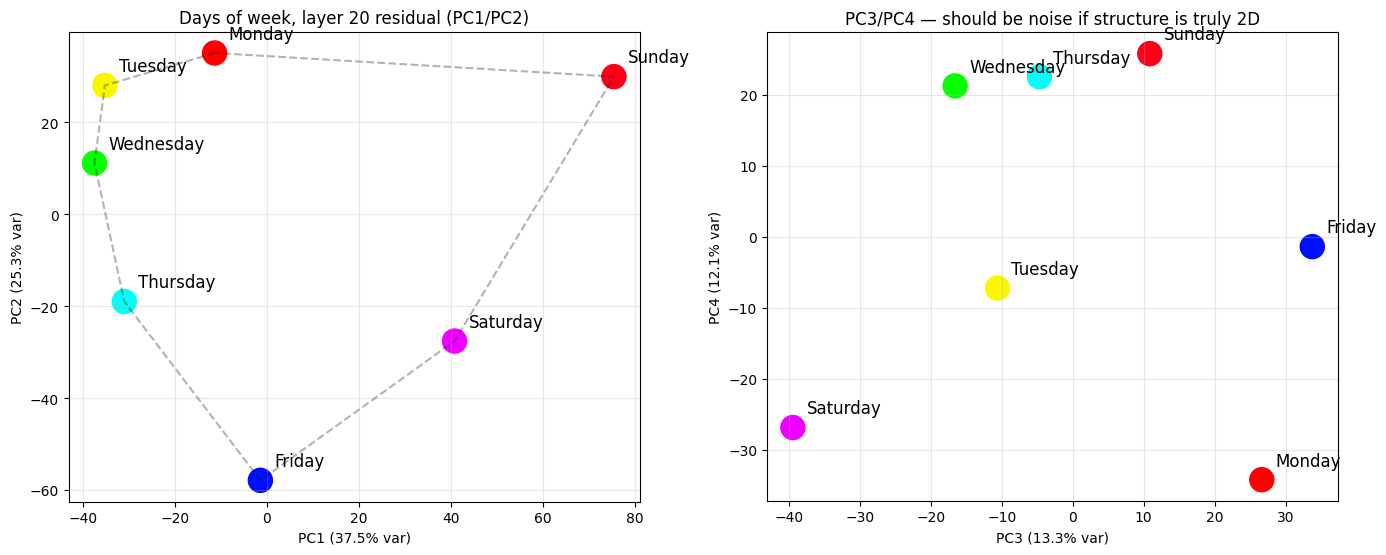

Variance explained: [0.3746124  0.2531936  0.13253301 0.12052244]
Cumulative: [0.3746124  0.62780595 0.76033896 0.8808614 ]


In [27]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Multiple templates per day to average out template-specific variation
TEMPLATES = [
    "Today is {}",
    "She said it was {}",
    "Yesterday was {}",
    "I'll see you on {}",
    "The meeting is on {}",
    "He arrived on {}",
    "The deadline was {}",
    "School starts on {}",
]

LAYER = 20

def last_token_resid(prompt: str, layer: int = LAYER) -> np.ndarray:
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(
        tokens,
        names_filter=f"blocks.{layer}.hook_resid_post",
        return_type=None,
    )
    return cache[f"blocks.{layer}.hook_resid_post"][0, -1].float().cpu().numpy()

# (7, n_templates, d_model)
day_vecs = np.stack([
    np.stack([last_token_resid(t.format(d)) for t in TEMPLATES])
    for d in DAYS
])

# Mean across templates → (7, d_model)
day_means = day_vecs.mean(axis=1)

# PCA to 4 components (we'll plot 1-2, but 3-4 are diagnostic)
pca = PCA(n_components=4)
day_pca = pca.fit_transform(day_means)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# PC1 vs PC2
ax = axes[0]
ax.scatter(day_pca[:, 0], day_pca[:, 1], s=300, c=range(7), cmap="hsv")
for i, day in enumerate(DAYS):
    ax.annotate(day, (day_pca[i, 0], day_pca[i, 1]),
                fontsize=12, xytext=(10, 10), textcoords="offset points")
# Connect in calendar order, close the loop
loop = list(range(7)) + [0]
ax.plot(day_pca[loop, 0], day_pca[loop, 1], "k--", alpha=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"Days of week, layer {LAYER} residual (PC1/PC2)")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

# PC3 vs PC4 — should look like noise if days are truly 2D
ax = axes[1]
ax.scatter(day_pca[:, 2], day_pca[:, 3], s=300, c=range(7), cmap="hsv")
for i, day in enumerate(DAYS):
    ax.annotate(day, (day_pca[i, 2], day_pca[i, 3]),
                fontsize=12, xytext=(10, 10), textcoords="offset points")
ax.set_xlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%} var)")
ax.set_ylabel(f"PC4 ({pca.explained_variance_ratio_[3]:.1%} var)")
ax.set_title("PC3/PC4 — should be noise if structure is truly 2D")
ax.set_aspect("equal")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Variance explained: {pca.explained_variance_ratio_}")
print(f"Cumulative: {np.cumsum(pca.explained_variance_ratio_)}")

Encoding residuals ->feature activations

In [28]:
def get_feature_acts(prompt: str, layer: int = 20):
      tokens = model.to_tokens(prompt)
      _, cache = model.run_with_cache(
          tokens,
          names_filter=f"blocks.{layer}.hook_resid_post",
          return_type=None,
      )
      resid = cache[f"blocks.{layer}.hook_resid_post"].squeeze(
  0).to(device).float()
      feature_acts = sae.encode(resid)          # fp32 in → fp32 out
      print("max act:", feature_acts.max().item(), "| nonzero:",  (feature_acts > 0).sum().item())
      return feature_acts, model.to_str_tokens(prompt)

Days-of-wwek SAE decoder PCA

In [29]:
# Find SAE features that activate on day prompts
def features_active_on(prompt: str, threshold: float = 1.0):
    acts, _ = get_feature_acts(prompt, layer=LAYER)
    active = (acts[-1] > threshold).nonzero().squeeze(-1)
    return active.cpu().numpy()

# Union of features active on any day prompt
day_feature_set = set()
for d in DAYS:
    for t in TEMPLATES:
        day_feature_set.update(features_active_on(t.format(d)).tolist())

day_features = sorted(day_feature_set)
print(f"Found {len(day_features)} candidate features active on day prompts")

# Get their decoder vectors → (n_features, d_model)
W_dec = sae.W_dec.float().cpu().numpy()  # (d_sae, d_model)
day_decoders = W_dec[day_features]

# PCA the decoder vectors
pca_dec = PCA(n_components=4)
dec_pca = pca_dec.fit_transform(day_decoders)

# This plot won't directly show a 7-day circle — it shows clustering 
# structure across ALL features active on day prompts. The circle 
# emerges when you find the subcluster of ~7-14 features that 
# specifically co-activate by day.
plt.figure(figsize=(8, 8))
plt.scatter(dec_pca[:, 0], dec_pca[:, 1], alpha=0.6)
plt.title("SAE decoder vectors for day-active features (PC1/PC2)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

max act: 2040.0 | nonzero: 7208
max act: 2040.0 | nonzero: 7313
max act: 2040.0 | nonzero: 7231
max act: 2040.0 | nonzero: 7475
max act: 2040.0 | nonzero: 7314
max act: 2040.0 | nonzero: 7234
max act: 2040.0 | nonzero: 7276
max act: 2040.0 | nonzero: 7285
max act: 2040.0 | nonzero: 7203
max act: 2040.0 | nonzero: 7308
max act: 2040.0 | nonzero: 7222
max act: 2040.0 | nonzero: 7475
max act: 2040.0 | nonzero: 7310
max act: 2040.0 | nonzero: 7239
max act: 2040.0 | nonzero: 7274
max act: 2040.0 | nonzero: 7282
max act: 2040.0 | nonzero: 7210
max act: 2040.0 | nonzero: 7308
max act: 2040.0 | nonzero: 7225
max act: 2040.0 | nonzero: 7475
max act: 2040.0 | nonzero: 7310
max act: 2040.0 | nonzero: 7238
max act: 2040.0 | nonzero: 7271
max act: 2040.0 | nonzero: 7280
max act: 2040.0 | nonzero: 7202
max act: 2040.0 | nonzero: 7314
max act: 2040.0 | nonzero: 7229
max act: 2040.0 | nonzero: 7475
max act: 2040.0 | nonzero: 7313
max act: 2040.0 | nonzero: 7238
max act: 2040.0 | nonzero: 7268
max act:

OutOfMemoryError: CUDA out of memory. Tried to allocate 144.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 103.81 MiB is free. Including non-PyTorch memory, this process has 14.46 GiB memory in use. Of the allocated memory 14.27 GiB is allocated by PyTorch, and 64.77 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Load temporal prompts: 
past, present, future, counterfactual and hypothetical

From Kaggle's imported dataset

In [25]:
import sys, os, glob
hits = glob.glob("/kaggle/input/**/temporal.py", recursive=True)
assert hits, "temporal.py not found under /kaggle/input — is the dataset attached?"
sys.path.insert(0, os.path.dirname(hits[0]))
from temporal import ALL_TEMPORAL_CATEGORIES

## Geometry at 8, 14, 20, 25 layers

In [14]:
LAYERS = [8, 14, 20, 25]

def last_token_resid(prompt: str, layer: int):
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(
        tokens,
        names_filter=f"blocks.{layer}.hook_resid_post",
        return_type=None,
    )
    return cache[f"blocks.{layer}.hook_resid_post"][0, -1].float()

# Compute category means at every layer
ORDERED_CATS = ["past", "present", "future", "counterfactual", "hypothetical"]

resid_means_by_layer = {}  # layer -> {cat: tensor(d_model,)}
for L in LAYERS:
    resid_means_by_layer[L] = {}
    for cat in ORDERED_CATS:
        vecs = [last_token_resid(p, L) for p in ALL_TEMPORAL_CATEGORIES[cat]]
        resid_means_by_layer[L][cat] = torch.stack(vecs).mean(0)
    print(f"Layer {L} done")

Layer 8 done
Layer 14 done
Layer 20 done
Layer 25 done


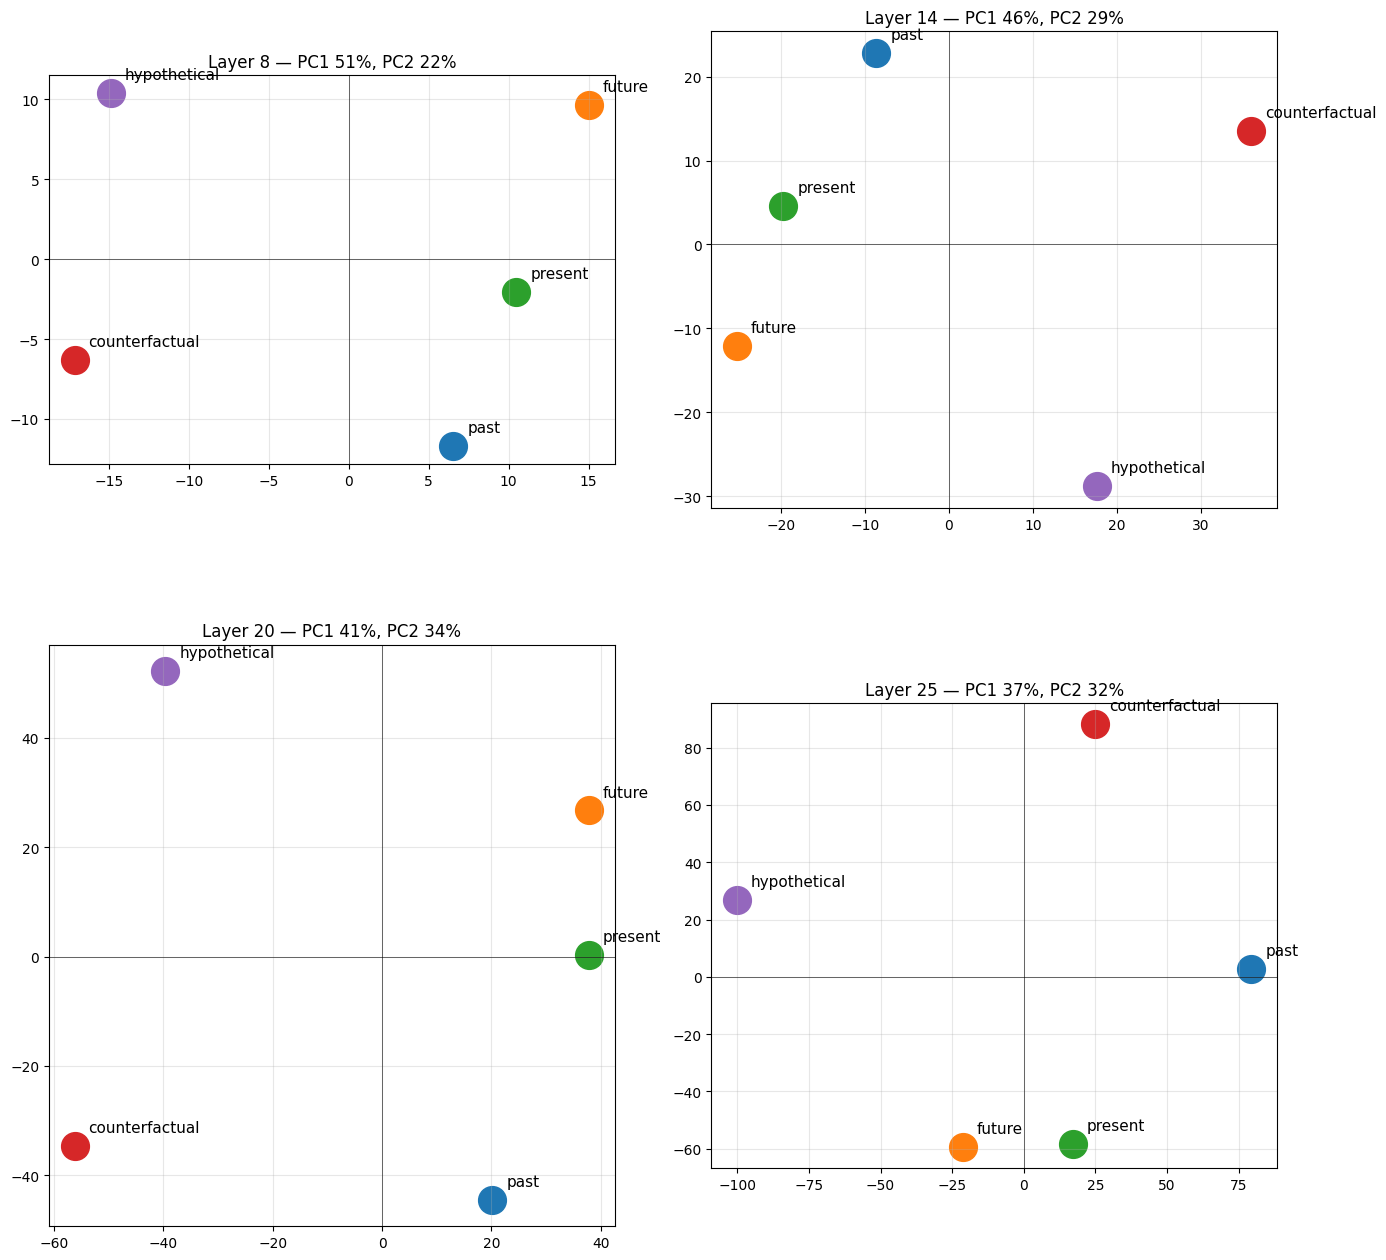

In [15]:
# Plot PCA grid: 2x2 layers, PC1/PC2 each
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax, L in zip(axes.flat, LAYERS):
    M = torch.stack([resid_means_by_layer[L][c] for c in ORDERED_CATS]).cpu().numpy()
    M = M - M.mean(0, keepdims=True)
    pca = PCA(n_components=2)
    P = pca.fit_transform(M)

    for i, cat in enumerate(ORDERED_CATS):
        ax.scatter(P[i, 0], P[i, 1], s=400, c=colors[i])
        ax.annotate(cat, (P[i, 0], P[i, 1]),
                    fontsize=11, xytext=(10, 10), textcoords="offset points")
    ax.set_title(f"Layer {L} — PC1 {pca.explained_variance_ratio_[0]:.0%}, "
                 f"PC2 {pca.explained_variance_ratio_[1]:.0%}")
    ax.axhline(0, color="k", lw=0.4); ax.axvline(0, color="k", lw=0.4)
    ax.grid(alpha=0.3); ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Temporal category means at layer 20

In [19]:
# === STEP 1: Compute category means (last-token aggregation) ===

from temporal import ALL_TEMPORAL_CATEGORIES

category_means_sae = {}  # category -> mean SAE activation vector (d_sae,)
category_means_resid = {}  # category -> mean residual stream vector (d_model,)

for cat_name, prompts in ALL_TEMPORAL_CATEGORIES.items():
    sae_vecs = []
    resid_vecs = []
    for p in prompts:
        # SAE features (uses your existing get_feature_acts)
        acts, _ = get_feature_acts(p, layer=20)
        sae_vecs.append(acts[-1])
        # Raw residual (for the Engels-style PCA)
        tokens = model.to_tokens(p)
        _, cache = model.run_with_cache(
            tokens, names_filter="blocks.20.hook_resid_post", return_type=None,
        )
        resid_vecs.append(cache["blocks.20.hook_resid_post"][0, -1].float())
    category_means_sae[cat_name]   = torch.stack(sae_vecs).mean(0)
    category_means_resid[cat_name] = torch.stack(resid_vecs).mean(0)
    print(f"{cat_name:>15}: {len(prompts)} prompts processed")

max act: 2040.0 | nonzero: 7539
max act: 2040.0 | nonzero: 7409
max act: 2040.0 | nonzero: 7524
max act: 2040.0 | nonzero: 7504
max act: 2040.0 | nonzero: 7503
max act: 2040.0 | nonzero: 7528
max act: 2040.0 | nonzero: 7508
max act: 2040.0 | nonzero: 7520
max act: 2040.0 | nonzero: 7691
max act: 2040.0 | nonzero: 7531
max act: 2040.0 | nonzero: 7645
max act: 2040.0 | nonzero: 7846
max act: 2040.0 | nonzero: 7893
max act: 2040.0 | nonzero: 7535
max act: 2040.0 | nonzero: 7723
max act: 2040.0 | nonzero: 7597
max act: 2040.0 | nonzero: 7454
max act: 2040.0 | nonzero: 7613
max act: 2040.0 | nonzero: 7564
max act: 2040.0 | nonzero: 7724
           past: 20 prompts processed
max act: 2040.0 | nonzero: 7547
max act: 2040.0 | nonzero: 7494
max act: 2040.0 | nonzero: 7498
max act: 2040.0 | nonzero: 7586
max act: 2040.0 | nonzero: 7653
max act: 2040.0 | nonzero: 7507
max act: 2040.0 | nonzero: 7781
max act: 2040.0 | nonzero: 7417
max act: 2040.0 | nonzero: 7550
max act: 2040.0 | nonzero: 7392
ma

## top differential features per category

In [20]:
# === STEP 2: Find candidate features per category (vs neutral timeless) ===

NP_URL = "https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/"

def top_features_vs_neutral(category_name, k=15):
    diff = category_means_sae[category_name] - category_means_sae["neutral"]
    top = torch.topk(diff, k)
    return pd.DataFrame({
        "feature_id":      top.indices.tolist(),
        "diff_score":      top.values.tolist(),
        f"{category_name}_mean": [category_means_sae[category_name][i].item() for i in top.indices],
        "neutral_mean":    [category_means_sae["neutral"][i].item()         for i in top.indices],
        "neuronpedia":     [NP_URL + str(i.item()) for i in top.indices],
    })

# For each temporal category, what are the top candidate features?
for cat in ["past", "present", "future", "counterfactual", "hypothetical"]:
    print(f"\n=== {cat.upper()} ===")
    print(top_features_vs_neutral(cat).to_string(index=False))
    


=== PAST ===
 feature_id  diff_score  past_mean  neutral_mean                                                    neuronpedia
       1858     24.0000    64.0000     40.000000  https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/1858
       2230     16.2500    16.2500      0.000000  https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/2230
       1548     15.5625    15.5625      0.000000  https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/1548
       2914     14.8125    16.1250      1.289062  https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/2914
      12545     14.1875    14.1875      0.000000 https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/12545
       6631     13.7500    52.2500     38.500000  https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/6631
       2229     13.0000    64.5000     51.500000  https://neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/2229
       2238     12.8125    26.0000     13.187500  https://neuronpedia.org/gemma-2-2b/20-ge

## temporal geometry PCA

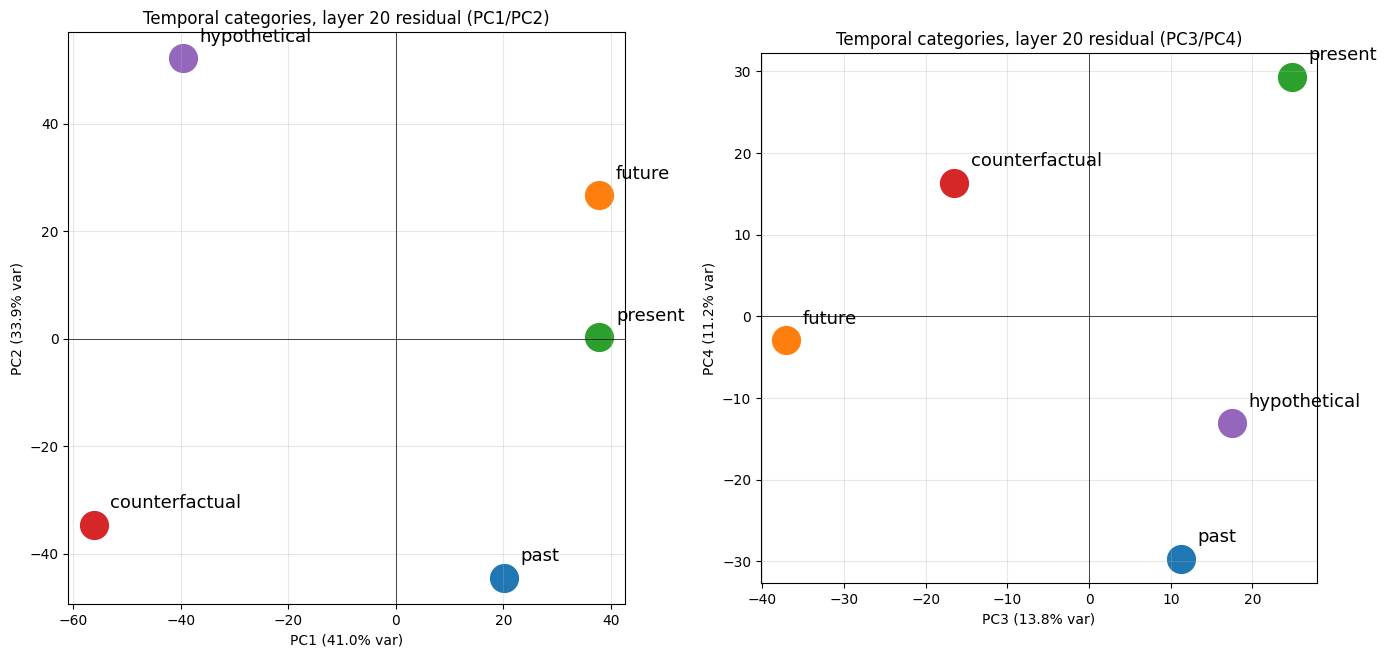

Variance explained: [0.4102727  0.33915818 0.13833533 0.11223382]
Cumulative:         [0.4102727  0.7494309  0.88776624 1.        ]


In [21]:
# === STEP 3: Geometry — PCA on category means ===

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

ORDERED_CATS = ["past", "present", "future", "counterfactual", "hypothetical"]

# Stack residual stream means → (5, d_model)
M = torch.stack([category_means_resid[c] for c in ORDERED_CATS]).cpu().numpy()

# Center (recommended for PCA)
M_centered = M - M.mean(0, keepdims=True)

pca = PCA(n_components=4)
M_pca = pca.fit_transform(M_centered)

# Plot PC1/PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]

for ax_idx, (px, py) in enumerate([(0, 1), (2, 3)]):
    ax = axes[ax_idx]
    for i, cat in enumerate(ORDERED_CATS):
        ax.scatter(M_pca[i, px], M_pca[i, py], s=400, c=colors[i], label=cat)
        ax.annotate(cat, (M_pca[i, px], M_pca[i, py]),
                    fontsize=13, xytext=(12, 12), textcoords="offset points")
    ax.set_xlabel(f"PC{px+1} ({pca.explained_variance_ratio_[px]:.1%} var)")
    ax.set_ylabel(f"PC{py+1} ({pca.explained_variance_ratio_[py]:.1%} var)")
    ax.set_title(f"Temporal categories, layer 20 residual (PC{px+1}/PC{py+1})")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)

plt.tight_layout()
plt.show()

print(f"Variance explained: {pca.explained_variance_ratio_}")
print(f"Cumulative:         {np.cumsum(pca.explained_variance_ratio_)}")